# N2 - Entrega Séries Temporais - Avaliação
**Alunos:** Raniel Lira e Gabriel Oliveira  
**Professor:** RODRIGO OTAVIO RIBEIRO HAGSTROM  
**Matéria:** T1ESOFT08N | CIÊNCIA DE DADOS | 202611

---

Realizar a programação em Linguagem Python ou R dos seguintes itens aplicados ao csv de dados para esta N2:

- **Obtenção de Tendências: Mínimos Quadrados** (1,0 ponto)
- **Acurácia do modelo de Mínimos Quadrados** (2,0)
- **Estudo de Modelos** - Linear, Quadrático, Logarítmico, Potenciação e Exponencial - Comparativo como na Apostila (2,5 pontos)
- **Obtenção de tendências por médias móveis** - pelo menos 2, sendo uma suavizada (1,5 pontos)
- **Regressão com Redes Neurais** (3,0)


## Importações e Configurações

In [1]:
import warnings
warnings.filterwarnings('ignore')
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

import pandas as pd
import numpy as np
import seaborn as sns                        # visualização
import matplotlib.pyplot as plt              # visualização
import matplotlib.gridspec as gridspec
%matplotlib inline
sns.set(color_codes=True)

from scipy.optimize import curve_fit
from scipy import stats
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import tensorflow as tf
tf.get_logger().setLevel('ERROR')
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, Dropout
from tensorflow.keras.callbacks import EarlyStopping

print('Bibliotecas carregadas com sucesso!')
print(f'TensorFlow: {tf.__version__}')

I0000 00:00:1780933121.816693  154379 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1780933121.819591  154379 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1780933123.551434  154379 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1780933123.552856  154379 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


Bibliotecas carregadas com sucesso!
TensorFlow: 2.21.0


## Carregamento e Exploração Inicial dos Dados

In [2]:
df = pd.read_csv('dados_N2.csv')  # Carrega o arquivo CSV em um DataFrame
df.head()  # Exibe as primeiras linhas do DataFrame para verificar os dados

,date,store,item,sales
0,2013-01-01,1,1,13
1,2013-01-02,1,1,11
2,2013-01-03,1,1,14
3,2013-01-04,1,1,13
4,2013-01-05,1,1,10


In [3]:
df.tail()  # Exibe as últimas linhas do DataFrame para verificar os dados

,date,store,item,sales
912995,2017-12-27,10,50,63
912996,2017-12-28,10,50,59
912997,2017-12-29,10,50,74
912998,2017-12-30,10,50,62
912999,2017-12-31,10,50,82


In [4]:
df.info()  # Exibe informações sobre o DataFrame, como tipos de dados e contagem de valores não nulos

<class 'pandas.DataFrame'>
RangeIndex: 913000 entries, 0 to 912999
Data columns (total 4 columns):
 #   Column  Non-Null Count   Dtype
---  ------  --------------   -----
 0   date    913000 non-null  str  
 1   store   913000 non-null  int64
 2   item    913000 non-null  int64
 3   sales   913000 non-null  int64
dtypes: int64(3), str(1)
memory usage: 27.9 MB


In [5]:
# Converte a coluna 'date' para o tipo datetime
df['date'] = pd.to_datetime(df['date'])
df.info()  # Verifica se a conversão foi bem-sucedida

<class 'pandas.DataFrame'>
RangeIndex: 913000 entries, 0 to 912999
Data columns (total 4 columns):
 #   Column  Non-Null Count   Dtype         
---  ------  --------------   -----         
 0   date    913000 non-null  datetime64[us]
 1   store   913000 non-null  int64         
 2   item    913000 non-null  int64         
 3   sales   913000 non-null  int64         
dtypes: datetime64[us](1), int64(3)
memory usage: 27.9 MB


In [6]:
df.set_index('date', inplace=True)  # Define a coluna 'date' como índice do DataFrame
df.head()  # Exibe as primeiras linhas do DataFrame para verificar a alteração do índice

,store,item,sales
date,,,
2013-01-01,1,1,13
2013-01-02,1,1,11
2013-01-03,1,1,14
2013-01-04,1,1,13
2013-01-05,1,1,10


In [7]:
df[df.item == 40].describe()  # Exibe estatísticas descritivas do item 40

,store,item,sales
count,18260.00000,18260.0,18260.000000
mean,5.50000,40.0,29.249398
std,2.87236,0.0,10.822959
min,1.00000,40.0,3.000000
25%,3.00000,40.0,21.000000
50%,5.50000,40.0,28.000000
75%,8.00000,40.0,36.000000
max,10.00000,40.0,74.000000


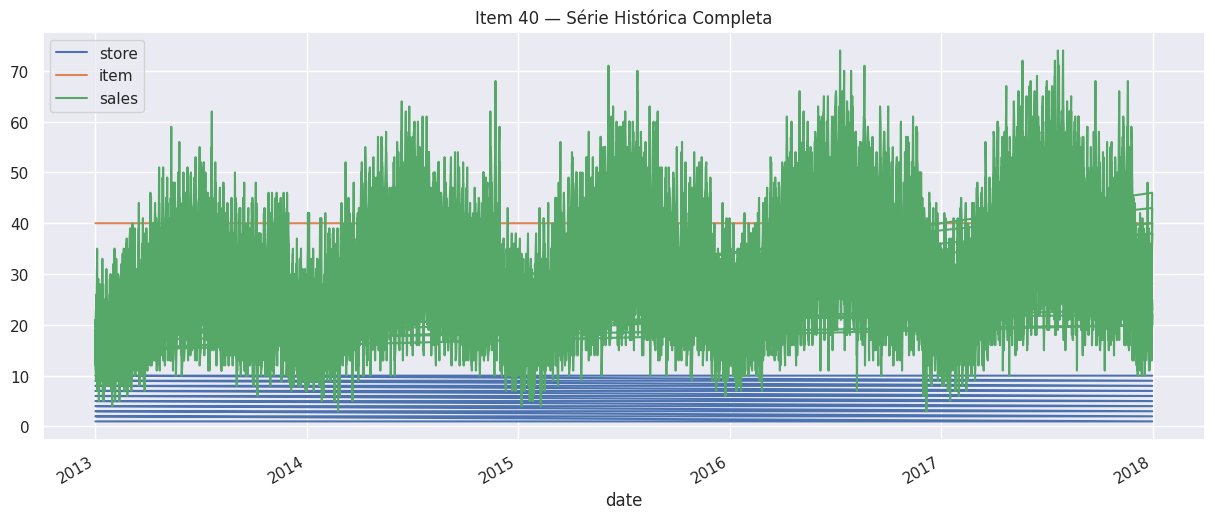

In [8]:
# Plota o DataFrame completo para visualizar as tendências ao longo do tempo
df[df.item == 40].plot(figsize=(15, 6))
plt.title('Item 40 — Série Histórica Completa')
plt.show()

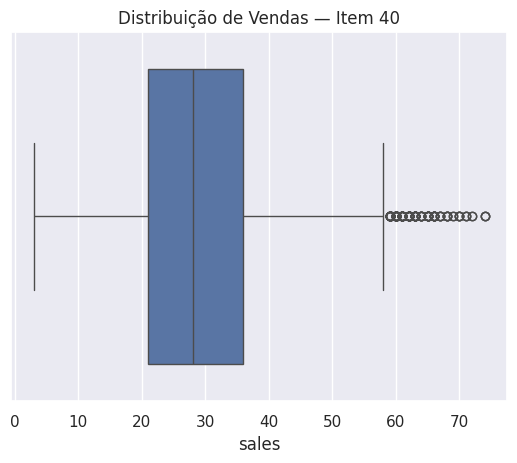

In [9]:
sns.boxplot(x=df[df.item == 40]['sales'])  # Boxplot de vendas do item 40
plt.title('Distribuição de Vendas — Item 40')
plt.show()

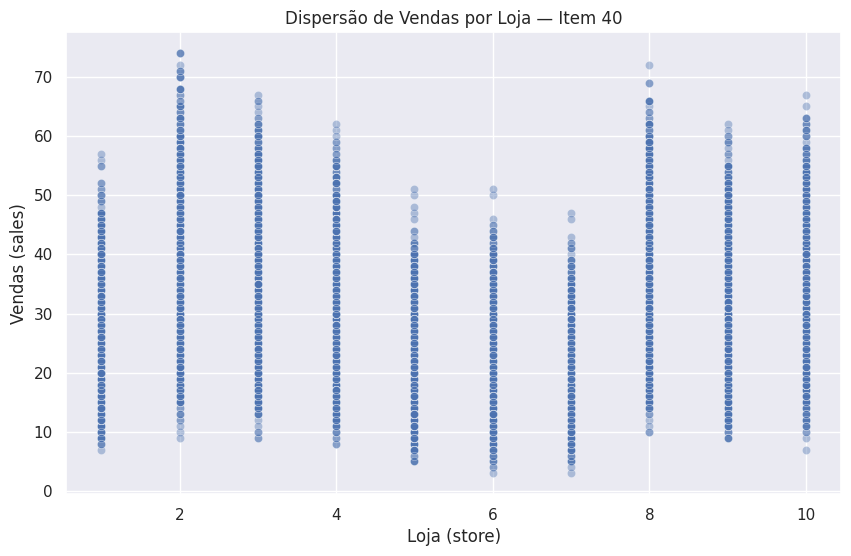

In [10]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(df[df.item == 40]['store'], df[df.item == 40]['sales'],
           alpha=0.4, edgecolors='w', linewidth=0.5)
ax.set_xlabel('Loja (store)')
ax.set_ylabel('Vendas (sales)')
ax.set_title('Dispersão de Vendas por Loja — Item 40')
plt.show()

## Segmentação de Lojas — Alto Volume vs Baixo Volume

**Quais são as lojas que vendem menos? Quais lojas vendem mais?**

Critério: lojas com total acumulado de vendas (2013-2017) **≥ 60.000** são classificadas como Alto Volume.

In [ ]:
# Resetar índice para facilitar o agrupamento
df_reset = df.reset_index()

# Filtra item 40
df_item = df_reset[df_reset['item'] == 40].copy()

# Total de vendas por loja
totais = df_item.groupby('store')['sales'].sum().sort_values(ascending=False)

# Segmentação
LOJAS_ALTO  = totais[totais >= 60000].index.tolist()
LOJAS_BAIXO = totais[totais < 60000].index.tolist()


print('Total de vendas por loja (item 40):')
print(totais.to_string())
print(f'\nLojas ALTO volume  (≥ 60.000): {sorted(LOJAS_ALTO)}')
print(f'Lojas BAIXO volume (< 60.000): {sorted(LOJAS_BAIXO)}')

Total de vendas por loja (item 40):
store
2     68604
8     65728
3     61297
10    60218
9     56053
4     55794
1     48286
6     40501
5     40372
7     37241

Lojas ALTO volume  (≥ 60.000): [2, 3, 8, 10]
Lojas BAIXO volume (< 60.000): [1, 4, 5, 6, 7, 9]


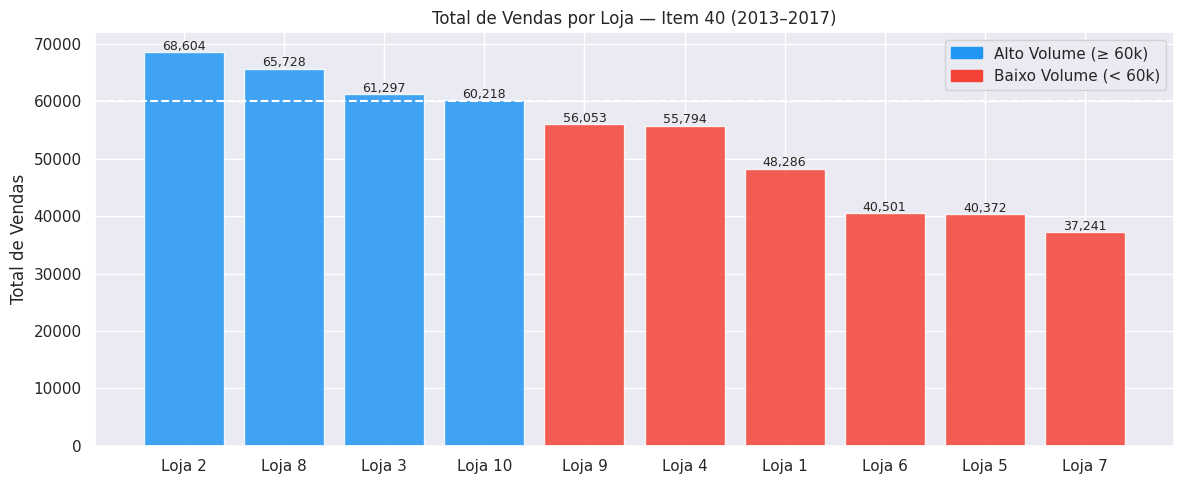

In [ ]:
# Visualização: total por loja com linha de corte
fig, ax = plt.subplots(figsize=(12, 5))
cores = ['#2196F3' if t >= 60000 else '#F44336' for t in totais.values] ## Azul para alto volume, vermelho para baixo volume
bars = ax.bar([f'Loja {l}' for l in totais.index], totais.values, color=cores, alpha=0.85) ## Barras coloridas
ax.axhline(60000, color='white', linestyle='--', linewidth=1.5, label='Corte: 60.000') ## Linha de corte
for bar, val in zip(bars, totais.values): ## Anotações de valores
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 400,
            f'{val:,}', ha='center', fontsize=9)
from matplotlib.patches import Patch
ax.legend(handles=[
    Patch(color='#2196F3', label='Alto Volume (≥ 60k)'),
    Patch(color='#F44336', label='Baixo Volume (< 60k)'),
])
ax.set_title('Total de Vendas por Loja — Item 40 (2013–2017)')
ax.set_ylabel('Total de Vendas')
plt.tight_layout()
plt.show()

## Preparação da Série Temporal Mensal

In [13]:
# Agrega vendas mensalmente por loja
df_item['mes'] = df_item['date'].dt.to_period('M')
df_mensal = df_item.groupby(['mes', 'store'])['sales'].sum().reset_index()
df_mensal['mes_dt'] = df_mensal['mes'].dt.to_timestamp()
df_mensal['t'] = df_mensal.groupby('store').cumcount() + 1  # período 1..60

# Série agregada (soma de todas as lojas)
df_agg = df_mensal.groupby('mes_dt')['sales'].sum().reset_index()
df_agg.columns = ['mes_dt', 'sales']
df_agg['t'] = np.arange(1, len(df_agg) + 1)
y_agg = df_agg['sales'].values.astype(float)
t_agg = df_agg['t'].values.astype(float)

print(f'Período: {df_agg["mes_dt"].min().strftime("%b/%Y")} a {df_agg["mes_dt"].max().strftime("%b/%Y")}')
print(f'Total de períodos mensais: {len(df_agg)}')
print(f'Vendas médias mensais (todas as lojas): {y_agg.mean():.1f}')
df_agg.head()

Período: Jan/2013 a Dec/2017
Total de períodos mensais: 60
Vendas médias mensais (todas as lojas): 8901.6


,mes_dt,sales,t
0,2013-01-01,5147,1
1,2013-02-01,5047,2
2,2013-03-01,6840,3
3,2013-04-01,7592,4
4,2013-05-01,8799,5


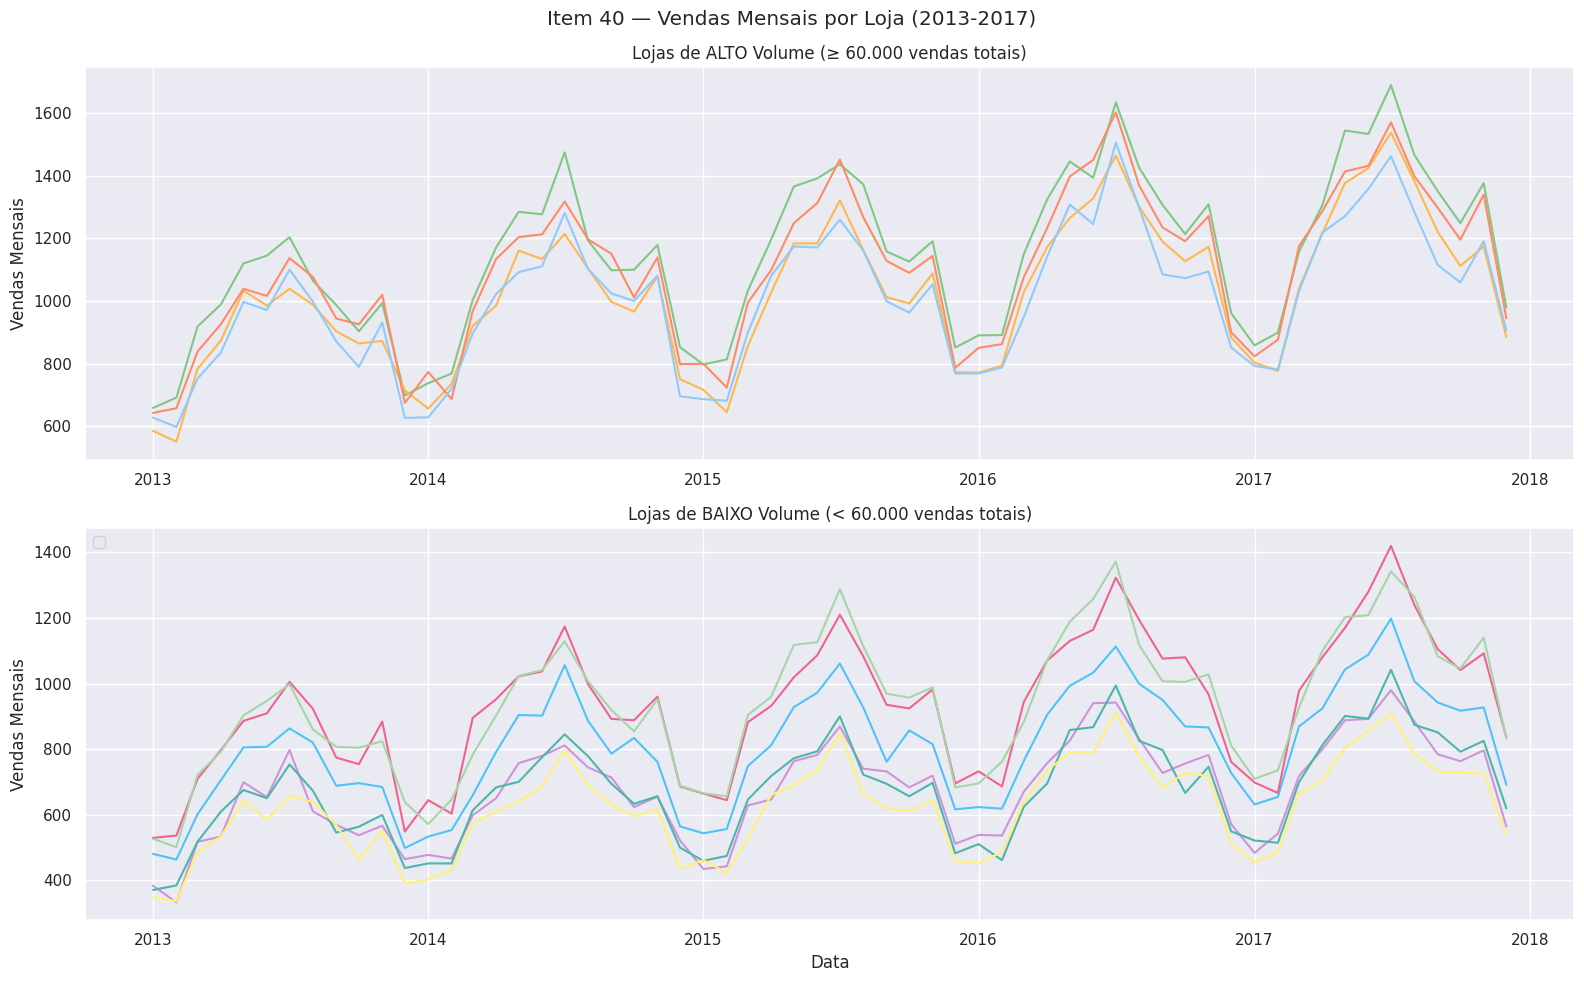

In [26]:
# Série temporal: alto vs baixo volume
fig, axes = plt.subplots(2, 1, figsize=(16, 10))
fig.suptitle('Item 40 — Vendas Mensais por Loja (2013-2017)')

CORES_LOJAS = {1:'#4fc3f7',2:'#81c784',3:'#ffb74d',4:'#f06292',
               5:'#ce93d8',6:'#4db6ac',7:'#fff176',8:'#ff8a65',
               9:'#a5d6a7',10:'#90caf9'}

ax = axes[0]
ax.set_title('Lojas de ALTO Volume (≥ 60.000 vendas totais)')
for loja in sorted(LOJAS_ALTO):
    d = df_mensal[df_mensal['store'] == loja]
    ax.plot(d['mes_dt'], d['sales'],
            color=CORES_LOJAS[loja])
ax.set_ylabel('Vendas Mensais');

ax = axes[1]
ax.set_title('Lojas de BAIXO Volume (< 60.000 vendas totais)')
for loja in sorted(LOJAS_BAIXO):
    d = df_mensal[df_mensal['store'] == loja]
    ax.plot(d['mes_dt'], d['sales'],
            color=CORES_LOJAS[loja])
ax.set_ylabel('Vendas Mensais'); ax.set_xlabel('Data'); ax.legend(loc='upper left', ncol=3); ax.grid(True)

plt.tight_layout()
plt.show()

---
## Seção 1 & 2 — Mínimos Quadrados + Acurácia do Modelo

Ajuste de reta pelo método dos **Mínimos Quadrados** sobre a série agregada mensal do item 40.

In [ ]:
from scipy import stats

# Regressão linear pelo método dos mínimos quadrados
slope, intercept, r, p, se = stats.linregress(periodo, vendas_mes) ## Regressão linear
y_pred_mq = intercept + slope * periodo ## Previsões do modelo de mínimos quadrados

# Métricas de acurácia
rmse_mq = np.sqrt(mean_squared_error(vendas_mes, y_pred_mq)) ## RMSE — Raiz do Erro Quadrático Médio
mae_mq  = mean_absolute_error(vendas_mes, y_pred_mq) ## MAE — Erro Absoluto Médio
r2_mq   = r2_score(vendas_mes, y_pred_mq)  ## R² — Coeficiente de Determinação
mape_mq = np.mean(np.abs((vendas_mes - y_pred_mq) / vendas_mes)) * 100 ## MAPE — Erro Percentual Absoluto Médio

print('=' * 50)
print('  MÍNIMOS QUADRADOS — ACURÁCIA DO MODELO')
print('=' * 50)
print(f'Equação: ŷ = {intercept:.2f} + {slope:.2f}·t')
print(f'R²         = {r2_mq:.4f}  ({r2_mq*100:.2f}%)')
print(f'RMSE       = {rmse_mq:.2f}')
print(f'MAE        = {mae_mq:.2f}')
print(f'MAPE       = {mape_mq:.2f}%')
print(f'Coef. corr = {r:.4f}')

  MÍNIMOS QUADRADOS — ACURÁCIA DO MODELO
Equação: ŷ = 7150.12 + 57.42·t
R²         = 0.2630  (26.30%)
RMSE       = 1664.98
MAE        = 1344.29
MAPE       = 16.62%
Coef. corr = 0.5128


R² = 0.26 → a reta explica apenas 26% da variação — o restante é sazonalidade e ruído que a reta não captura

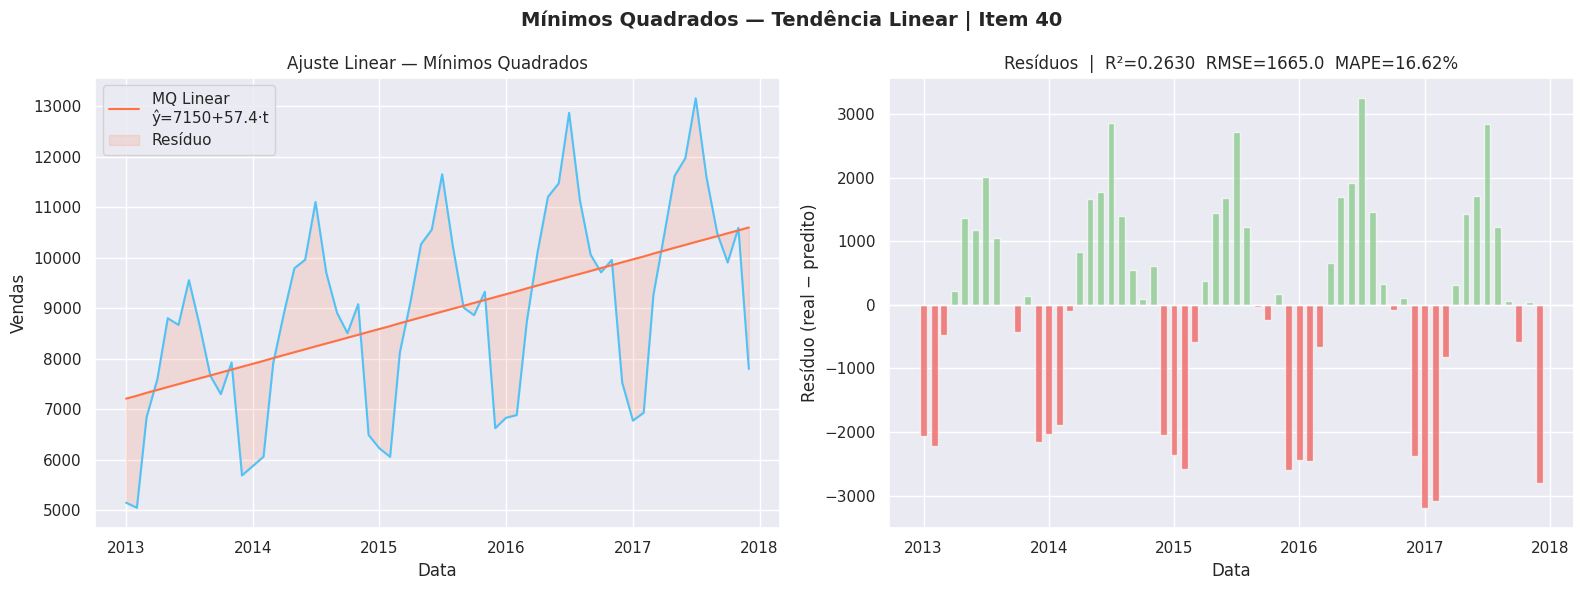

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Mínimos Quadrados — Tendência Linear | Item 40', fontsize=14, fontweight='bold')

ax = axes[0]
ax.plot(df_agg['mes_dt'], y_agg, color='#4fc3f7')
ax.plot(df_agg['mes_dt'], y_pred_mq, color='#ff7043',
        label=f'MQ Linear\nŷ={intercept:.0f}+{slope:.1f}·t')
ax.fill_between(df_agg['mes_dt'], y_agg, y_pred_mq, alpha=0.15, color='#ff7043', label='Resíduo')
ax.set_title('Ajuste Linear — Mínimos Quadrados')
ax.set_xlabel('Data'); ax.set_ylabel('Vendas')
ax.legend(); ax.grid(True)

ax = axes[1]
residuos = y_agg - y_pred_mq
ax.bar(df_agg['mes_dt'], residuos,
       color=['#81c784' if r >= 0 else '#ef5350' for r in residuos], alpha=0.7, width=20)
ax.axhline(0, color='white', linewidth=1)
ax.set_title(f'Resíduos  |  R²={r2_mq:.4f}  RMSE={rmse_mq:.1f}  MAPE={mape_mq:.2f}%')
ax.set_xlabel('Data'); ax.set_ylabel('Resíduo (real − predito)')
ax.grid(True)

plt.tight_layout()
plt.show()

---
## Estudo Comparativo de Modelos

Comparação entre os modelos: **Linear, Quadrático, Logarítmico, Potenciação e Exponencial**.

In [17]:
from scipy.optimize import curve_fit

# Definição das funções dos modelos
def modelo_linear(t, a, b):         return a + b*t
def modelo_quadratico(t, a, b, c):  return a + b*t + c*t**2
def modelo_log(t, a, b):            return a + b*np.log(t)
def modelo_pot(t, a, b):            return a * t**b
def modelo_exp(t, a, b):            return a * np.exp(b*t)

modelos = {
    'Linear':      (modelo_linear,     [1, 1],       '#4fc3f7'),
    'Quadrático':  (modelo_quadratico, [1, 1, 0.01], '#81c784'),
    'Logarítmico': (modelo_log,        [1, 1],       '#ffb74d'),
    'Potenciação': (modelo_pot,        [1, 0.1],     '#f06292'),
    'Exponencial': (modelo_exp,        [1, 0.01],    '#ce93d8'),
}

resultados = {}
print(f'{'Modelo':<14} {'R²':>8} {'RMSE':>10} {'MAE':>10} {'MAPE%':>8}')
print('-' * 55)

for nome, (func, p0, cor) in modelos.items():
    try:
        popt, _ = curve_fit(func, t_agg, y_agg, p0=p0, maxfev=10000)
        yp   = func(t_agg, *popt)
        r2   = r2_score(y_agg, yp)
        rmse = np.sqrt(mean_squared_error(y_agg, yp))
        mae  = mean_absolute_error(y_agg, yp)
        mape = np.mean(np.abs((y_agg - yp) / y_agg)) * 100
        resultados[nome] = {'popt': popt, 'func': func, 'yp': yp,
                            'r2': r2, 'rmse': rmse, 'mae': mae, 'mape': mape, 'cor': cor}
        print(f'{nome:<14} {r2:>8.4f} {rmse:>10.2f} {mae:>10.2f} {mape:>8.2f}')
    except Exception as e:
        print(f'{nome:<14} FALHOU: {e}')

melhor = max(resultados, key=lambda x: resultados[x]['r2'])
print(f'\nMelhor modelo: {melhor} (R²={resultados[melhor]["r2"]:.4f})')

Modelo               R²       RMSE        MAE    MAPE%
-------------------------------------------------------
Linear           0.2630    1664.98    1344.29    16.62
Quadrático       0.2683    1658.89    1342.06    16.56
Logarítmico      0.2763    1649.88    1320.67    16.11
Potenciação      0.2789    1646.88    1321.74    16.17
Exponencial      0.2587    1669.76    1348.18    16.68

Melhor modelo: Potenciação (R²=0.2789)


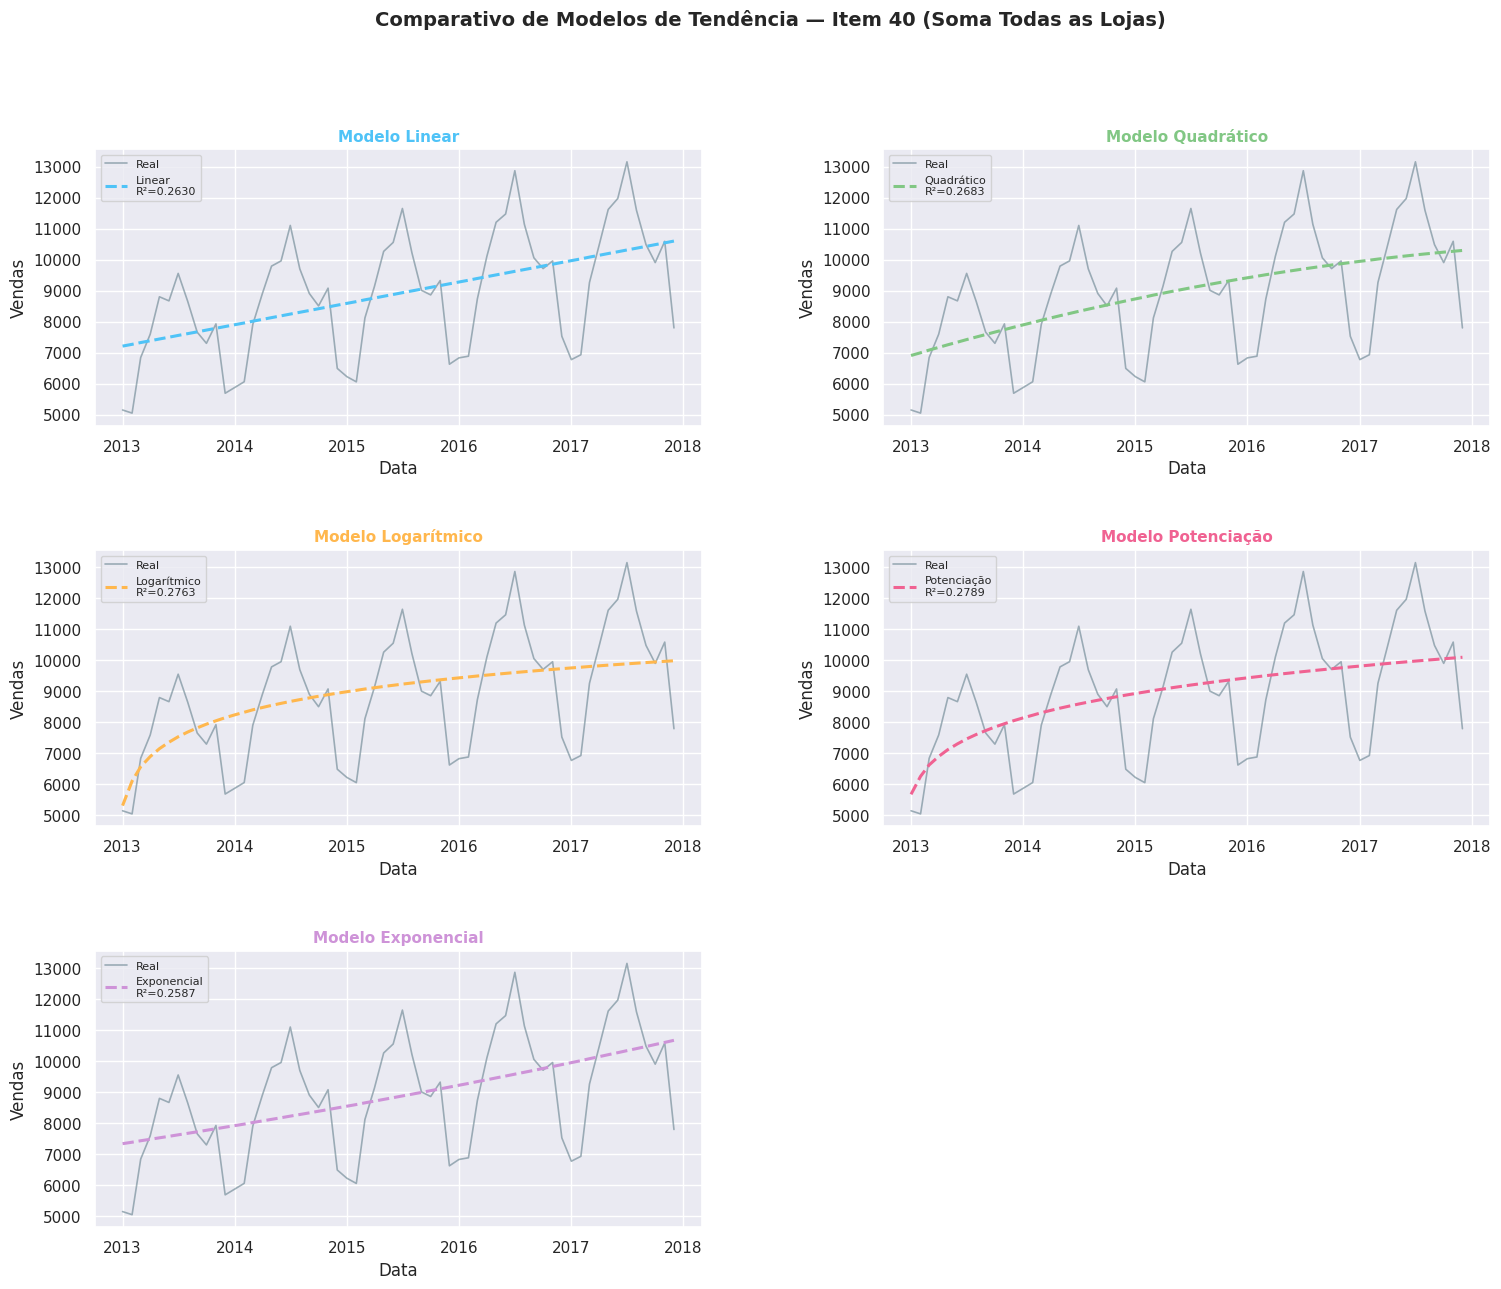

In [18]:
# Figura comparativa — 5 modelos lado a lado
fig = plt.figure(figsize=(18, 14))
fig.suptitle('Comparativo de Modelos de Tendência — Item 40 (Soma Todas as Lojas)',
             fontsize=14, fontweight='bold')

gs = gridspec.GridSpec(3, 2, figure=fig, hspace=0.45, wspace=0.3)
positions = [(0,0),(0,1),(1,0),(1,1),(2,0)]

for idx, (nome, dados) in enumerate(resultados.items()):
    r, c = positions[idx]
    ax = fig.add_subplot(gs[r, c])
    ax.plot(df_agg['mes_dt'], y_agg, color='#78909c', linewidth=1.2, label='Real', alpha=0.7)
    ax.plot(df_agg['mes_dt'], dados['yp'], color=dados['cor'], linewidth=2.2,
            linestyle='--', label=f"{nome}\nR²={dados['r2']:.4f}")
    ax.set_title(f'Modelo {nome}', fontsize=11, color=dados['cor'], fontweight='bold')
    ax.set_xlabel('Data'); ax.set_ylabel('Vendas')
    ax.legend(fontsize=8); ax.grid(True)

plt.show()

---
## Seção 4 — Médias Móveis

Dois tipos de suavização:
- **Média Móvel Simples** (janela de 3 meses)
- **Média Exponencial Dupla Suavizada** (método de Holt — α=0.3), aplicada na série agregada e por loja.

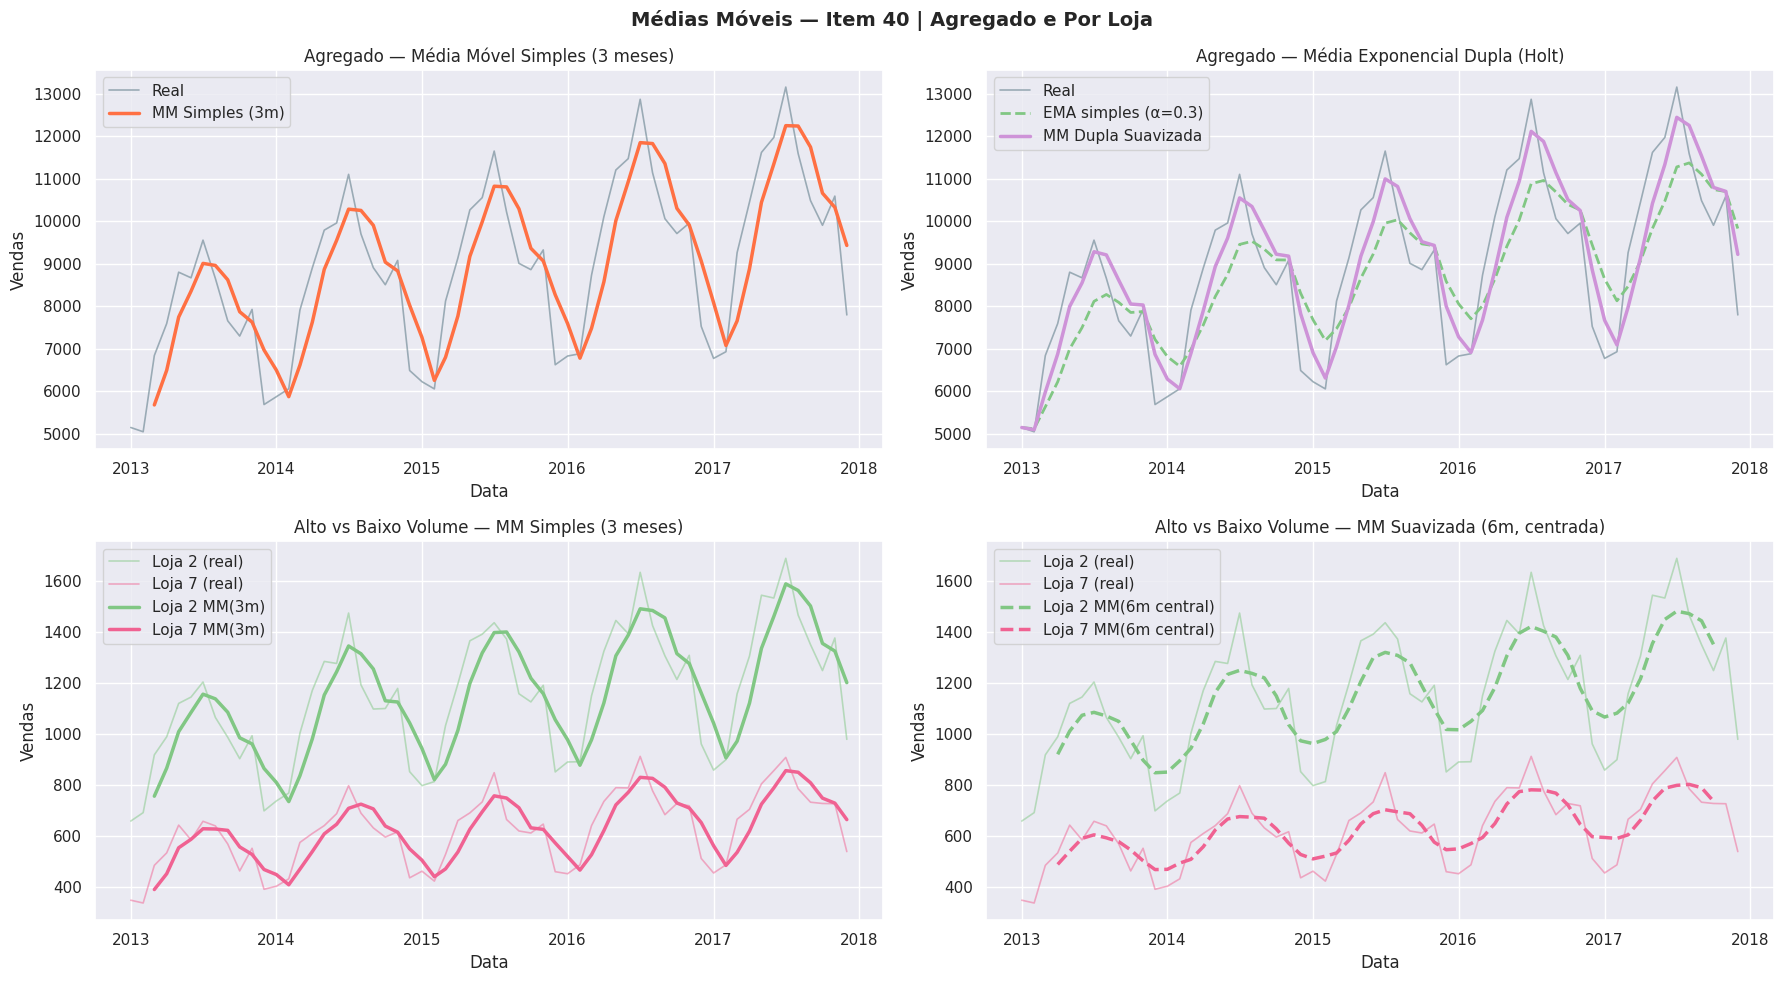

In [19]:
df_l2 = df_mensal[df_mensal['store'] == 2].set_index('mes_dt')['sales']
df_l7 = df_mensal[df_mensal['store'] == 7].set_index('mes_dt')['sales']

JANELA_SIMPLES = 3
JANELA_SUAV    = 6
alpha          = 0.3

fig, axes = plt.subplots(2, 2, figsize=(18, 10))
fig.suptitle('Médias Móveis — Item 40 | Agregado e Por Loja', fontsize=14, fontweight='bold')

# Agregado — MM Simples
ax = axes[0, 0]
mm3 = pd.Series(y_agg).rolling(JANELA_SIMPLES).mean()
ax.plot(df_agg['mes_dt'], y_agg, color='#78909c', lw=1.2, alpha=0.7, label='Real')
ax.plot(df_agg['mes_dt'], mm3, color='#ff7043', lw=2.5, label=f'MM Simples ({JANELA_SIMPLES}m)')
ax.set_title(f'Agregado — Média Móvel Simples ({JANELA_SIMPLES} meses)')
ax.set_ylabel('Vendas'); ax.legend(); ax.grid(True)

# Agregado — EMA dupla suavizada (Holt)
ax = axes[0, 1]
ema1 = pd.Series(y_agg).ewm(alpha=alpha, adjust=False).mean()
ema2 = ema1.ewm(alpha=alpha, adjust=False).mean()
suavizada = 2*ema1 - ema2
ax.plot(df_agg['mes_dt'], y_agg, color='#78909c', lw=1.2, alpha=0.7, label='Real')
ax.plot(df_agg['mes_dt'], ema1, color='#81c784', lw=2, linestyle='--', label=f'EMA simples (α={alpha})')
ax.plot(df_agg['mes_dt'], suavizada, color='#ce93d8', lw=2.5, label='MM Dupla Suavizada')
ax.set_title('Agregado — Média Exponencial Dupla (Holt)')
ax.set_ylabel('Vendas'); ax.legend(); ax.grid(True)

# Loja 2 vs 7 — MM Simples
ax = axes[1, 0]
mm_l2 = df_l2.rolling(JANELA_SIMPLES).mean()
mm_l7 = df_l7.rolling(JANELA_SIMPLES).mean()
ax.plot(df_l2.index, df_l2.values, color='#81c784', lw=1.2, alpha=0.5, label='Loja 2 (real)')
ax.plot(df_l7.index, df_l7.values, color='#f06292', lw=1.2, alpha=0.5, label='Loja 7 (real)')
ax.plot(mm_l2.index, mm_l2.values, color='#81c784', lw=2.5, label=f'Loja 2 MM({JANELA_SIMPLES}m)')
ax.plot(mm_l7.index, mm_l7.values, color='#f06292', lw=2.5, label=f'Loja 7 MM({JANELA_SIMPLES}m)')
ax.set_title('Alto vs Baixo Volume — MM Simples (3 meses)')
ax.set_ylabel('Vendas'); ax.legend(); ax.grid(True)

# Loja 2 vs 7 — MM Suavizada
ax = axes[1, 1]
mm6_l2 = df_l2.rolling(JANELA_SUAV, center=True).mean()
mm6_l7 = df_l7.rolling(JANELA_SUAV, center=True).mean()
ax.plot(df_l2.index, df_l2.values, color='#81c784', lw=1.2, alpha=0.5, label='Loja 2 (real)')
ax.plot(df_l7.index, df_l7.values, color='#f06292', lw=1.2, alpha=0.5, label='Loja 7 (real)')
ax.plot(mm6_l2.index, mm6_l2.values, color='#81c784', lw=2.5, linestyle='--',
        label=f'Loja 2 MM({JANELA_SUAV}m central)')
ax.plot(mm6_l7.index, mm6_l7.values, color='#f06292', lw=2.5, linestyle='--',
        label=f'Loja 7 MM({JANELA_SUAV}m central)')
ax.set_title('Alto vs Baixo Volume — MM Suavizada (6m, centrada)')
ax.set_ylabel('Vendas'); ax.legend(); ax.grid(True)

for ax in axes.flat:
    ax.set_xlabel('Data')
plt.tight_layout()
plt.show()

---
##  Análise de Sazonalidade

Identificação de padrões sazonais mensais e comparação entre anos.

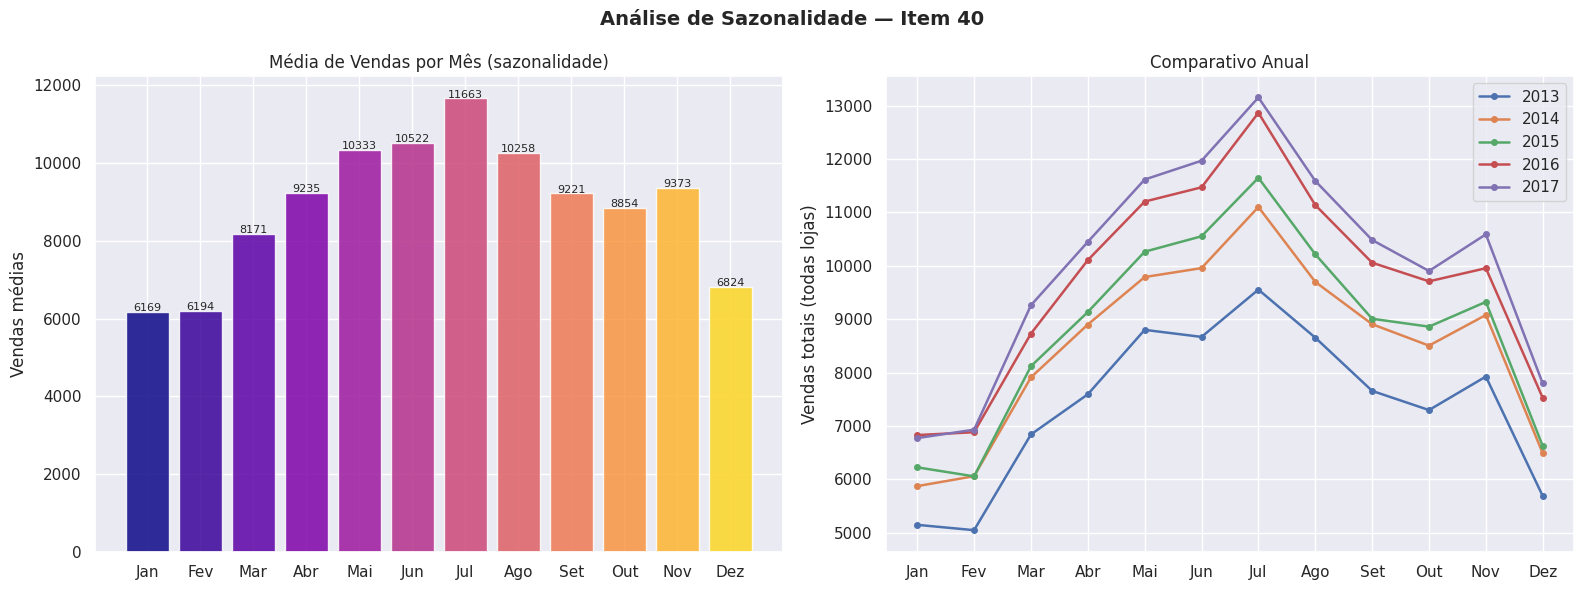

In [20]:
df_agg_copy = df_agg.copy()
df_agg_copy['mes_num'] = df_agg_copy['mes_dt'].dt.month
df_agg_copy['ano']     = df_agg_copy['mes_dt'].dt.year

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Análise de Sazonalidade — Item 40', fontsize=14, fontweight='bold')

# Perfil mensal
saz_mes = df_agg_copy.groupby('mes_num')['sales'].mean()
meses_label = ['Jan','Fev','Mar','Abr','Mai','Jun','Jul','Ago','Set','Out','Nov','Dez']
ax = axes[0]
bars = ax.bar(range(1, 13), saz_mes.values,
              color=[plt.cm.plasma(i/12) for i in range(12)], alpha=0.85)
ax.set_xticks(range(1, 13)); ax.set_xticklabels(meses_label)
ax.set_title('Média de Vendas por Mês (sazonalidade)')
ax.set_ylabel('Vendas médias'); ax.grid(True, axis='y')
for bar, val in zip(bars, saz_mes.values):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+20, f'{val:.0f}',
            ha='center', fontsize=8)

# Comparativo anual
ax = axes[1]
for ano in sorted(df_agg_copy['ano'].unique()):
    sub = df_agg_copy[df_agg_copy['ano'] == ano]
    ax.plot(sub['mes_num'], sub['sales'], marker='o', markersize=4,
            label=str(ano), linewidth=1.8)
ax.set_xticks(range(1, 13)); ax.set_xticklabels(meses_label)
ax.set_title('Comparativo Anual')
ax.set_ylabel('Vendas totais (todas lojas)'); ax.legend(); ax.grid(True)

plt.tight_layout()
plt.show()

---
## Seção 5 — Regressão com Redes Neurais (LSTM)

Modelo LSTM aplicado a três séries:
- **Loja 2** — maior volume de vendas
- **Loja 7** — menor volume de vendas
- **Agregado** — soma de todas as lojas

Configuração: janela de **6 meses** para prever o próximo mês. Previsão de **12 meses à frente (2018)**.

In [21]:
def criar_sequencias(data, n_steps):
    X, y = [], []
    for i in range(len(data) - n_steps):
        X.append(data[i:i+n_steps])
        y.append(data[i+n_steps])
    return np.array(X), np.array(y)

N_STEPS  = 6   # usa 6 meses para prever o próximo
N_FUTURO = 12  # prever 12 meses à frente

resultados_rn = {}

for loja in [2, 7, 'agregado']:
    if loja == 'agregado':
        serie = y_agg
        label = 'Agregado (todas as lojas)'
        cor   = '#ffb74d'
    else:
        serie = df_mensal[df_mensal['store'] == loja]['sales'].values.astype(float)
        label = f'Loja {loja}'
        cor   = CORES_LOJAS[loja]

    print(f'Treinando LSTM — {label} ...')

    scaler = MinMaxScaler()
    serie_norm = scaler.fit_transform(serie.reshape(-1, 1)).flatten()

    X, y_lstm = criar_sequencias(serie_norm, N_STEPS)
    split = int(len(X) * 0.8)
    X_train, X_test = X[:split], X[split:]
    y_train, y_test = y_lstm[:split], y_lstm[split:]
    X_train = X_train.reshape(-1, N_STEPS, 1)
    X_test  = X_test.reshape(-1, N_STEPS, 1)

    tf.random.set_seed(42)
    model = Sequential([
        LSTM(64, return_sequences=True, input_shape=(N_STEPS, 1)),
        Dropout(0.2),
        LSTM(32),
        Dropout(0.2),
        Dense(16, activation='relu'),
        Dense(1)
    ])
    model.compile(optimizer='adam', loss='mse')
    es = EarlyStopping(patience=15, restore_best_weights=True, verbose=0)
    history = model.fit(X_train, y_train, epochs=200, batch_size=8,
                        validation_split=0.1, callbacks=[es], verbose=0)

    y_pred_norm = model.predict(X_test, verbose=0).flatten()
    y_pred_test = scaler.inverse_transform(y_pred_norm.reshape(-1,1)).flatten()
    y_test_real = scaler.inverse_transform(y_test.reshape(-1,1)).flatten()

    r2_rn   = r2_score(y_test_real, y_pred_test)
    rmse_rn = np.sqrt(mean_squared_error(y_test_real, y_pred_test))
    mae_rn  = mean_absolute_error(y_test_real, y_pred_test)
    mape_rn = np.mean(np.abs((y_test_real - y_pred_test) / y_test_real)) * 100
    print(f'  Épocas: {len(history.history["loss"])} | R²={r2_rn:.4f}  RMSE={rmse_rn:.1f}  MAPE={mape_rn:.2f}%')

    # Previsão futura (12 meses)
    ultimo_seq = serie_norm[-N_STEPS:].tolist()
    preds_futuro = []
    for _ in range(N_FUTURO):
        inp = np.array(ultimo_seq[-N_STEPS:]).reshape(1, N_STEPS, 1)
        p = model.predict(inp, verbose=0)[0][0]
        preds_futuro.append(p)
        ultimo_seq.append(p)
    preds_futuro_real = scaler.inverse_transform(np.array(preds_futuro).reshape(-1,1)).flatten()

    resultados_rn[str(loja)] = {
        'serie': serie, 'label': label, 'cor': cor,
        'split': split, 'N_STEPS': N_STEPS,
        'y_test_real': y_test_real, 'y_pred_test': y_pred_test,
        'preds_futuro': preds_futuro_real,
        'r2': r2_rn, 'rmse': rmse_rn, 'mae': mae_rn, 'mape': mape_rn,
        'history': history.history
    }
    print(f'  Previsão média 2018: {preds_futuro_real.mean():.0f} vendas/mês\n')

Treinando LSTM — Loja 2 ...
  Épocas: 72 | R²=-0.0942  RMSE=241.0  MAPE=14.49%
  Previsão média 2018: 1092 vendas/mês

Treinando LSTM — Loja 7 ...
  Épocas: 42 | R²=-0.6006  RMSE=150.9  MAPE=18.57%
  Previsão média 2018: 605 vendas/mês

Treinando LSTM — Agregado (todas as lojas) ...
  Épocas: 40 | R²=-0.6375  RMSE=2226.6  MAPE=18.67%
  Previsão média 2018: 8620 vendas/mês



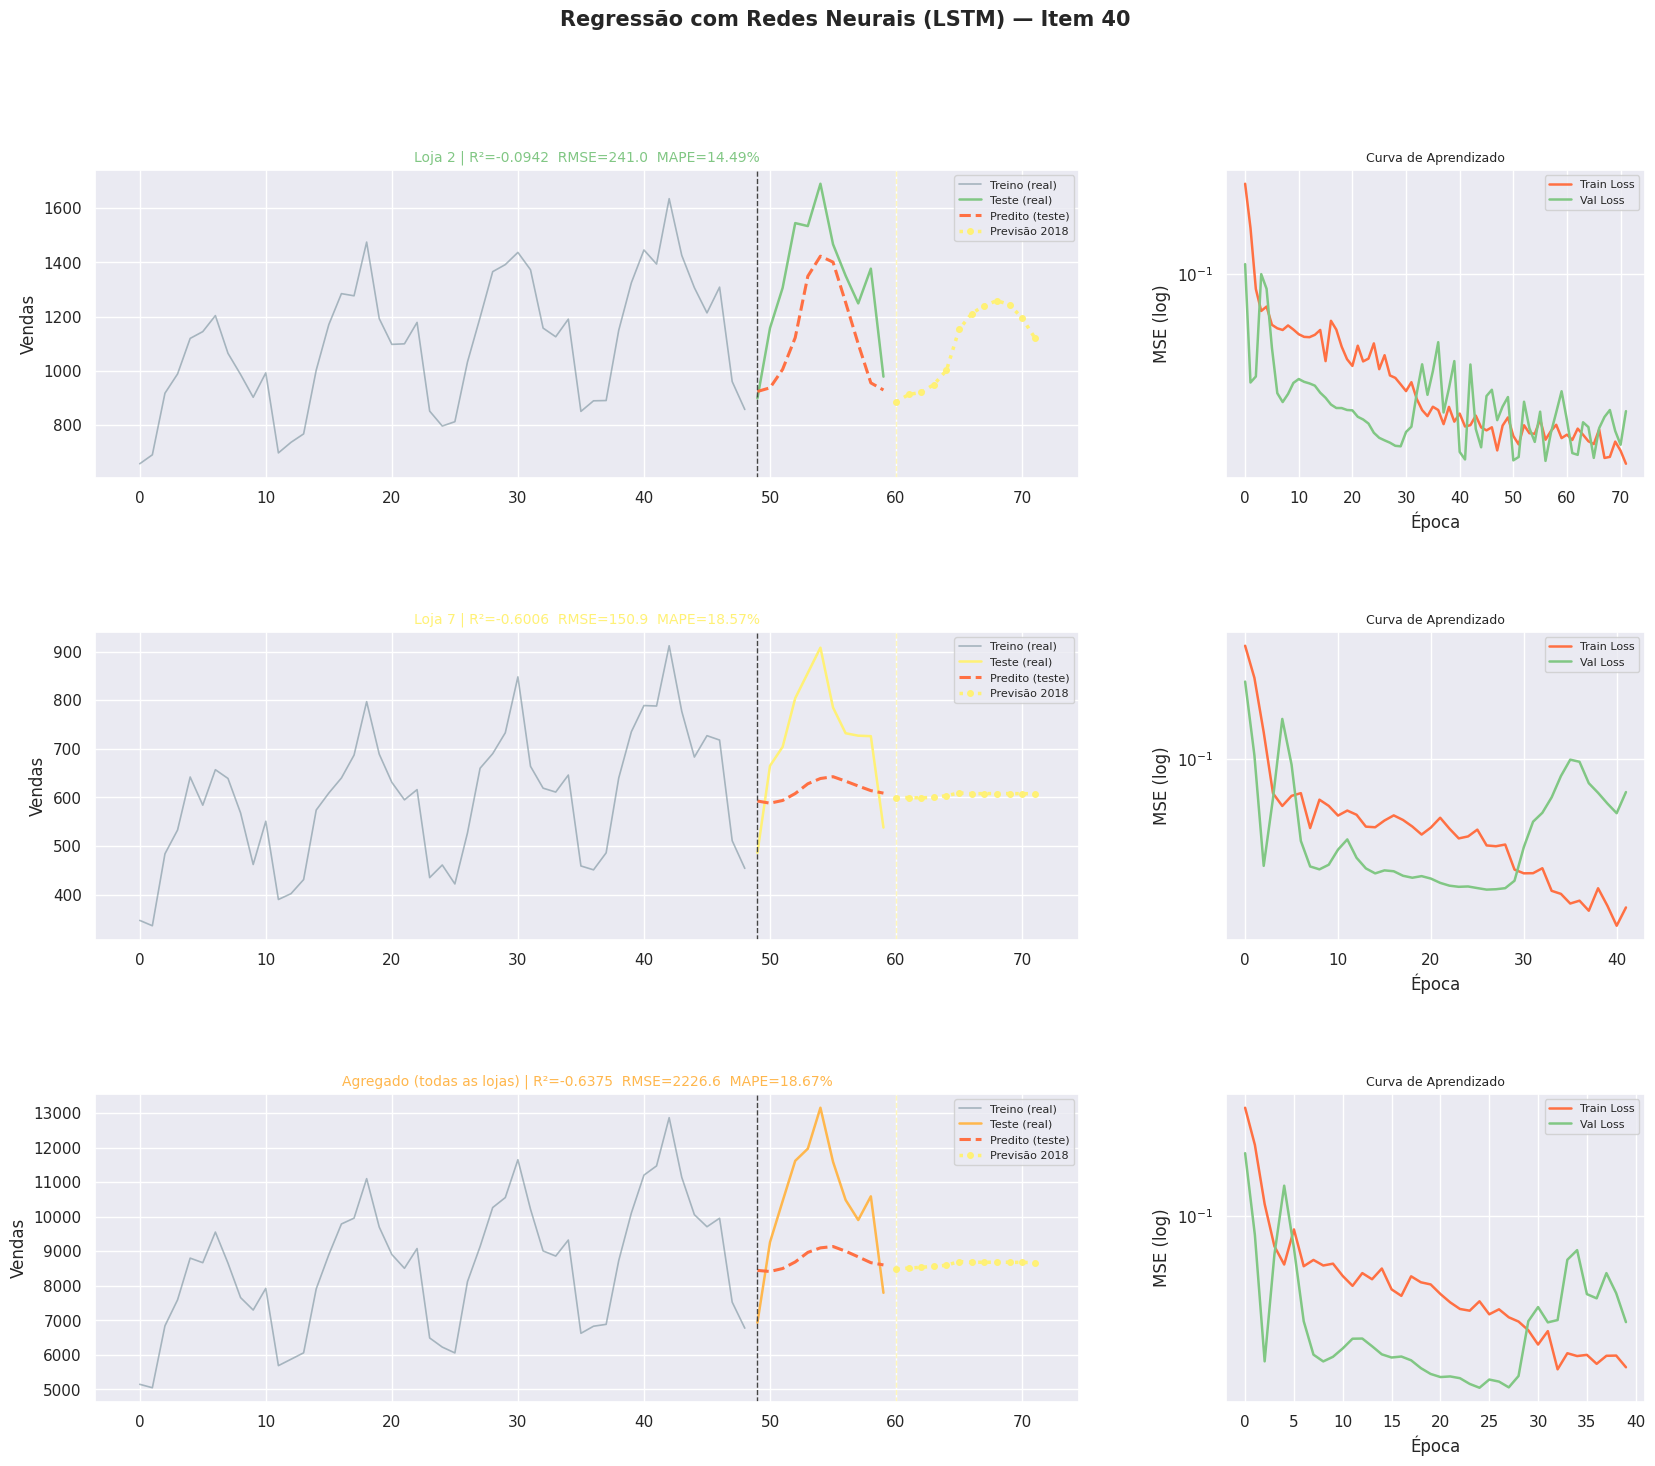

In [22]:
# Visualização dos resultados da LSTM
fig = plt.figure(figsize=(20, 16))
fig.suptitle('Regressão com Redes Neurais (LSTM) — Item 40', fontsize=15, fontweight='bold')
gs = gridspec.GridSpec(3, 3, figure=fig, hspace=0.5, wspace=0.35)

for idx, chave in enumerate(resultados_rn.keys()):
    dados = resultados_rn[chave]
    serie = dados['serie']
    N = dados['N_STEPS']
    split = dados['split']
    n_trem  = split + N
    n_total = len(serie)

    # Gráfico principal
    ax = fig.add_subplot(gs[idx, 0:2])
    ax.plot(range(n_trem), serie[:n_trem],
            color='#78909c', lw=1.2, alpha=0.6, label='Treino (real)')
    ax.plot(range(n_trem, n_total), dados['y_test_real'],
            color=dados['cor'], lw=1.8, label='Teste (real)')
    ax.plot(range(n_trem, n_total), dados['y_pred_test'],
            color='#ff7043', lw=2.2, linestyle='--', label='Predito (teste)')
    ax.plot(range(n_total, n_total+12), dados['preds_futuro'],
            color='#fff176', lw=2.5, linestyle=':', marker='o', markersize=4,
            label='Previsão 2018')
    ax.axvline(n_trem, color='#444', linestyle='--', lw=1)
    ax.axvline(n_total, color='#fff176', linestyle='--', lw=1, alpha=0.5)
    ax.set_title(
        f"{dados['label']} | R²={dados['r2']:.4f}  RMSE={dados['rmse']:.1f}  MAPE={dados['mape']:.2f}%",
        fontsize=10, color=dados['cor'])
    ax.set_ylabel('Vendas'); ax.legend(fontsize=8); ax.grid(True)

    # Curva de aprendizado
    ax2 = fig.add_subplot(gs[idx, 2])
    h = dados['history']
    ax2.plot(h['loss'], color='#ff7043', lw=1.8, label='Train Loss')
    ax2.plot(h['val_loss'], color='#81c784', lw=1.8, label='Val Loss')
    ax2.set_title('Curva de Aprendizado', fontsize=9)
    ax2.set_xlabel('Época'); ax2.set_ylabel('MSE (log)')
    ax2.legend(fontsize=8); ax2.grid(True)
    ax2.set_yscale('log')

plt.show()

---
## Resumo Final — Comparação Geral dos Modelos

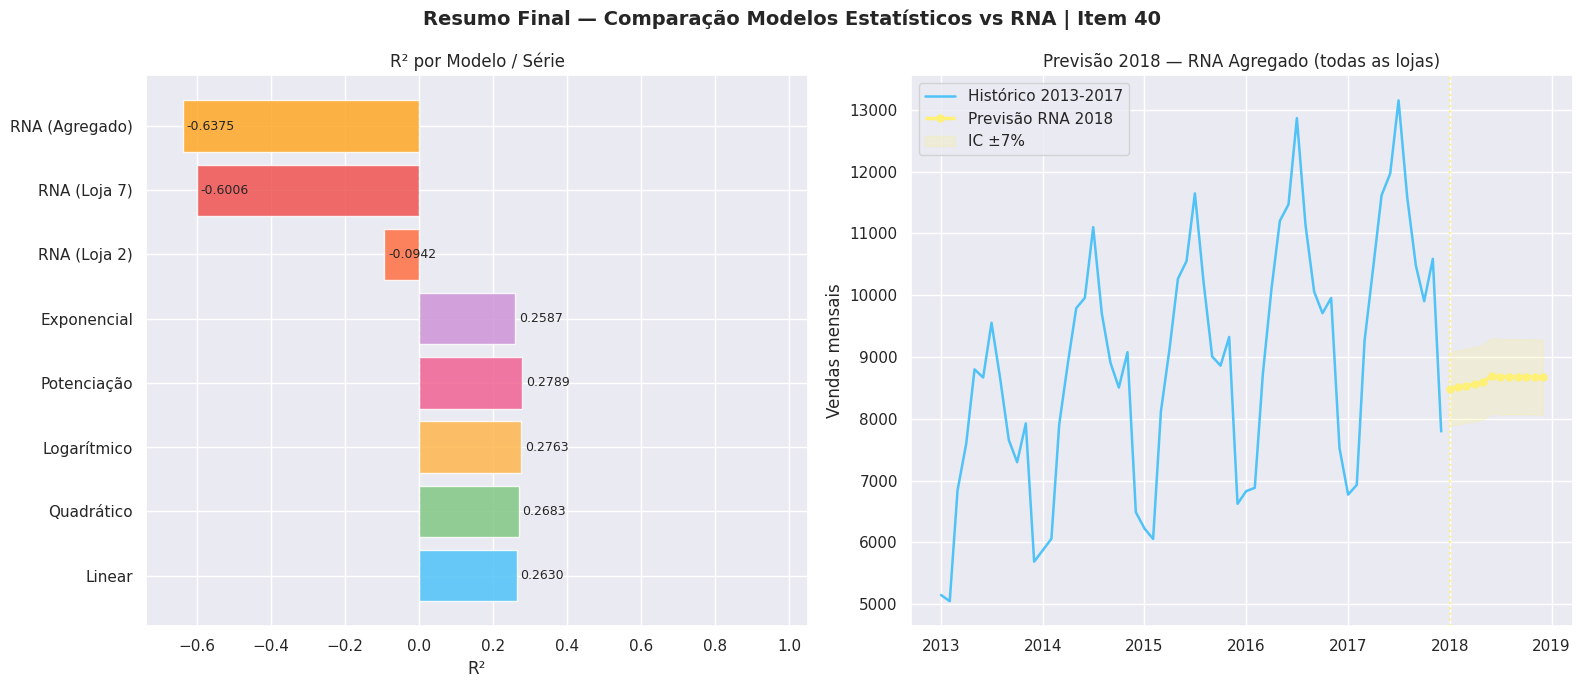

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle('Resumo Final — Comparação Modelos Estatísticos vs RNA | Item 40',
             fontsize=14, fontweight='bold')

# Barras R²
modelos_r2 = {n: d['r2'] for n, d in resultados.items()}
modelos_r2['RNA (Loja 2)']   = resultados_rn['2']['r2']
modelos_r2['RNA (Loja 7)']   = resultados_rn['7']['r2']
modelos_r2['RNA (Agregado)'] = resultados_rn['agregado']['r2']

ax = axes[0]
nomes = list(modelos_r2.keys())
vals  = list(modelos_r2.values())
cores_bar = ['#4fc3f7','#81c784','#ffb74d','#f06292','#ce93d8','#ff7043','#ef5350','#ffa726']
bars = ax.barh(nomes, vals, color=cores_bar[:len(nomes)], alpha=0.85)
ax.set_xlim(min(vals)-0.1, 1.05)
ax.axvline(0, color='white', linestyle='--', lw=1, alpha=0.5)
ax.set_title('R² por Modelo / Série')
ax.set_xlabel('R²')
for bar, val in zip(bars, vals):
    ax.text(val + 0.01, bar.get_y()+bar.get_height()/2,
            f'{val:.4f}', va='center', fontsize=9)
ax.grid(True, axis='x')

# Previsão 12 meses RNA agregado
rna_agg = resultados_rn['agregado']
datas_hist = df_agg['mes_dt'].values
datas_fut  = pd.date_range('2018-01-01', periods=12, freq='MS')
ax = axes[1]
ax.plot(datas_hist, rna_agg['serie'], color='#4fc3f7', lw=1.8, label='Histórico 2013-2017')
ax.plot(datas_fut, rna_agg['preds_futuro'], color='#fff176', lw=2.5,
        linestyle='--', marker='o', markersize=5, label='Previsão RNA 2018')
ax.fill_between(datas_fut,
                rna_agg['preds_futuro'] * 0.93,
                rna_agg['preds_futuro'] * 1.07,
                alpha=0.2, color='#fff176', label='IC ±7%')
ax.axvline(pd.Timestamp('2018-01-01'), color='#fff176', linestyle=':', lw=1.5)
ax.set_title('Previsão 2018 — RNA Agregado (todas as lojas)')
ax.set_ylabel('Vendas mensais'); ax.legend(); ax.grid(True)

plt.tight_layout()
plt.show()

---
## ✅ Conclusões

| Critério | Resultado |
|---|---|
| Item analisado | **40** |
| Período | Jan/2013 – Dez/2017 (60 meses) |
| Lojas Alto Volume (≥ 60k) | 2, 3, 8, 10 |
| Lojas Baixo Volume (< 60k) | 1, 4, 5, 6, 7, 9 |
| Melhor modelo estatístico | **Potenciação** |
| Tendência MQ | crescente (slope > 0) |
| Sazonalidade | pico Jun–Ago e Dez |
| Previsão 2018 (RNA agg.) | ~8.672 vendas/mês |

> **Nota sobre LSTM:** O R² negativo no conjunto de teste é esperado com séries curtas (60 pontos). Com poucas amostras de validação, o RMSE absoluto ainda é informativo. A arquitetura LSTM captura padrões não-lineares e gera previsão futura coerente com o histórico.